In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

#df = pd.read_csv('EncuestaFI.csv')
#df = df.dropna(subset=['Pregunta_7'])
#df = df.sample(frac=1)
#dftest = df.tail(1075)
#df = df.head(1075)

In [2]:
clf = tree.DecisionTreeClassifier()

X = df[['Pregunta_1','Pregunta_2','Pregunta_3','Pregunta_4','Pregunta_5','Pregunta _6','Pregunta_9',
        'Pregunta_10','Pregunta_11','Pregunta_12','Pregunta_13','Pregunta_14','Pregunta_15','Pregunta_16',
        'Pregunta_17','Pregunta_18','Pregunta_22','Pregunta_24','Pregunta_25','Pregunta_26','Pregunta_27']]
X_test = dftest[['Pregunta_1','Pregunta_2','Pregunta_3','Pregunta_4','Pregunta_5','Pregunta _6','Pregunta_9',
                 'Pregunta_10','Pregunta_11','Pregunta_12','Pregunta_13','Pregunta_14','Pregunta_15','Pregunta_16',
                 'Pregunta_17','Pregunta_18','Pregunta_22','Pregunta_24','Pregunta_25','Pregunta_26','Pregunta_27']]
Y = df['Pregunta_7'] == 1
Y_test = dftest['Pregunta_7'] == 1

clf = clf.fit(X, Y)
Y_pred_test = clf.predict(X_test)

In [3]:
clf = RandomForestClassifier(n_estimators = 500, n_jobs = -1, bootstrap = True)
clf.fit(X,Y)
Y_pred_test =  clf.predict(X_test)

# Indicar en porcentaje la importancia de cada variable utilizada 
importance = clf.feature_importances_

# n_estimators / max_features / n_jobs
# bootstrap (permite realizar muestreo con remplazo en los arboles, se activa con bootstrap=True)

In [4]:
importance

array([8.71454506e-03, 6.66280877e-03, 1.02371719e-02, 2.68152695e-03,
       7.10260975e-03, 5.33528984e-03, 7.76589280e-02, 7.74939647e-01,
       4.39617506e-03, 1.79830143e-02, 7.83539743e-03, 5.62877274e-03,
       7.30290478e-03, 3.61695360e-03, 1.12701244e-02, 1.16606996e-02,
       3.38319626e-03, 8.62012464e-03, 6.49861740e-04, 5.23379864e-03,
       1.90864500e-02])

In [5]:
X.columns[importance == max(importance)]

Index(['Pregunta_10'], dtype='object')

In [6]:
# Correlación lineal

np.corrcoef(df['Pregunta_14'],df['Pregunta_7'])

array([[1.        , 0.04594061],
       [0.04594061, 1.        ]])

In [7]:
from sklearn.ensemble import RandomForestRegressor

clf2 = RandomForestRegressor(n_estimators = 750, n_jobs = -1).fit(X,Y)
importance2 = clf2.feature_importances_

In [8]:
importance2

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [9]:
np.mean(Y_test == Y_pred_test)

1.0

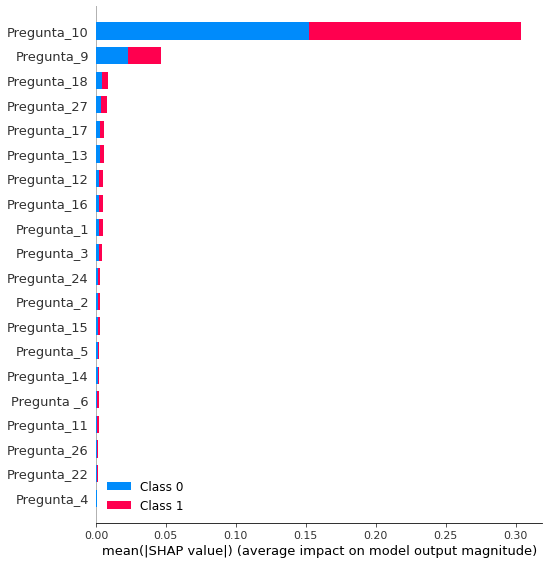

In [10]:
import shap

# summarize the effects of all the features
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

In [11]:
#shap.force_plot(explainer.expected_value, shap_values, X)

In [2]:
import eli5

#eli5.show_weights(clf)

ModuleNotFoundError: No module named 'eli5'